In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jenkspy
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import confusion_matrix, classification_report

In [80]:
# 1. Load your dataset
Flu_weather = pd.read_csv('NY_Flu_Weather_Final_Weekly.csv')

Flu_weather.head()

,County,Year,Month,Season,Region,Week,Week Ending Date,Disease,Infected,Avg household size,...,Latitude,Longitude,Prob_infected,County_Density,Ending Date,avg_temp_prior_week,avg_humidity_prior_week,avg_dew_point_prior_week,avg_precip_prior_week,avg_wind_speed_prior_week
0,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_A,4,2.3,...,42.601,-73.977,0.000013,582.162575,2009-10-10,52.136235,75.422893,44.082307,0.082677,11.513748
1,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_B,0,2.3,...,42.601,-73.977,0.000000,582.162575,2009-10-10,52.136235,75.422893,44.082307,0.082677,11.513748
2,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_UNSPECIFIED,0,2.3,...,42.601,-73.977,0.000000,582.162575,2009-10-10,52.136235,75.422893,44.082307,0.082677,11.513748
3,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,41,10/17/2009,INFLUENZA_A,11,2.3,...,42.601,-73.977,0.000036,582.162575,2009-10-17,39.730165,68.109046,29.425700,0.042745,7.608064
4,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,41,10/17/2009,INFLUENZA_B,0,2.3,...,42.601,-73.977,0.000000,582.162575,2009-10-17,39.730165,68.109046,29.425700,0.042745,7.608064


In [67]:
def calculate_rsi(df):
    """
    Calculates the Resource Strain Index (RSI) based on weather stress factors.
    Assumes df contains: 'avg_temp', 'avg_humidity', and 'avg_dewpoint'
    """
    
    # 1. Define the 'Ideal' Maxima from your dataset 
    # (These should represent the warmest/most humid points in your data)
    T_max = df['avg_temp_prior_week'].max()
    H_max = df['avg_humidity_prior_week'].max()
    D_max = df['avg_dew_point_prior_week'].max()

    # 2. Calculate the Inversions
    # Lower temp/humidity/dewpoint = Higher Stress Score
    df['temp_stress'] = T_max - df['avg_temp_prior_week']
    df['hum_stress'] = H_max - df['avg_humidity_prior_week']
    df['dew_stress'] = D_max - df['avg_dew_point_prior_week']

    # 3. Aggregate into a single Index (RSI)
    # We take the mean of the three stress components
    df['RSI'] = (df['temp_stress'] + df['hum_stress'] + df['dew_stress']) / 3

    # Clean up intermediate columns to keep the dataframe lean
    df = df.drop(columns=['temp_stress', 'hum_stress', 'dew_stress'])
    
    return df

# Apply to your main dataframe
Flu_weather = calculate_rsi(Flu_weather)

print(f"RSI Range: {Flu_weather['RSI'].min():.2f} to {Flu_weather['RSI'].max():.2f}")

RSI Range: 4.36 to 57.66


In [ ]:
# 1. Prepare your Features and Target
# Using only live weather data to avoid data leakage
X = Flu_weather[['RSI', 'avg_precip_prior_week', 'avg_wind_speed_prior_week']]
y = Flu_weather['Prob_infected']

# Log-transforming the target helps the ensemble model handle the 'spikes' in your data
y_log = np.log1p(y)

# 2. Train/Test Split
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 3. The Ensemble Method: Gradient Boosting
# This is the 'Brain' that learns the weather-to-infection patterns
model_gb = GradientBoostingRegressor(
    n_estimators=200,    #Lower number of trees to prevent overfitting with limited features
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42
)

model_gb.fit(X_train, y_train_log)




# Try lagging different features to see if it improves the model
# Also add a loss function that penalizes underestimation more than overestimation, since underestimating risk is more dangerous in this context.
# Can also over sample the high-risk weeks to give the model more examples of those critical scenarios.
# In presentation explain how we come up with categories


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [83]:
# 1. Get predictions on your training set
train_preds = model_gb.predict(X_train) 

breaks = jenkspy.jenks_breaks(train_preds, n_classes=4)

print(f"Model-Derived Thresholds: {breaks}")

Model-Derived Thresholds: [np.float64(-5.769773573470007e-06), np.float64(2.4189905969394037e-05), np.float64(5.0486290798621156e-05), np.float64(0.00014509511996675298), np.float64(0.001569684502719744)]


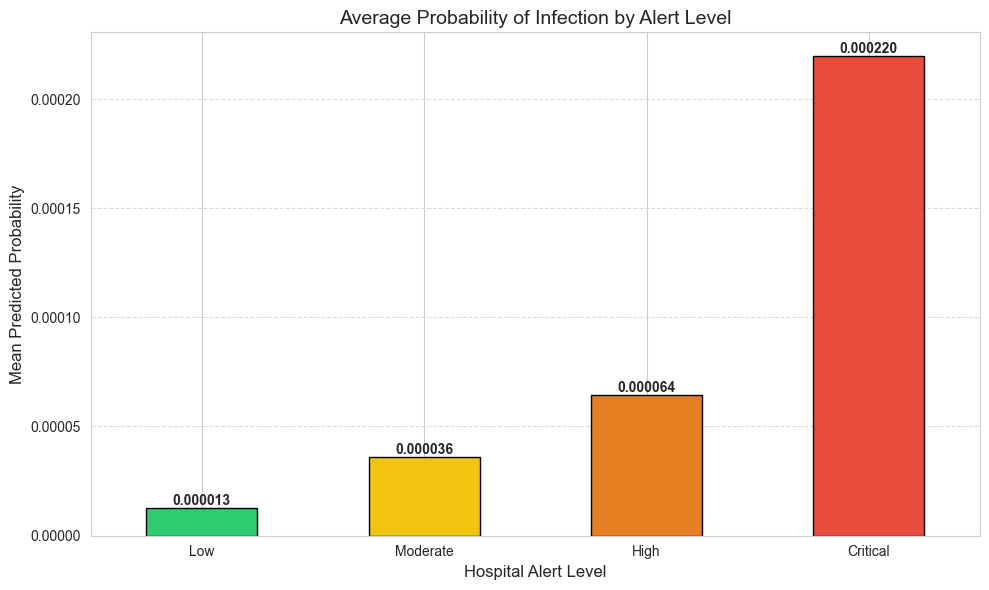

In [87]:

y_pred_probs = model_gb.predict(X_test)
y_test_probs = np.expm1(y_test_log)  # Convert back to original scale for comparison

# Define the results DataFrame
# We align the actual values and predicted values side-by-side
results = pd.DataFrame({
    'actual_prob': y_test_probs,    # The real infection data from your test set
    'pred_prob': y_pred_probs  # What your model thinks the infection risk is
})


# 1. Define your specific thresholds and labels
# Note: I replaced the negative min with 0 for cleaner reporting
breaks = [0, 2.41899e-05, 5.04862e-05, 0.00014509, 0.00156968]
labels = ['Low', 'Moderate', 'High', 'Critical']

# 2. Assign each prediction to a bin (Assuming 'results' is your DF)
# 'include_lowest=True' ensures the 0 value is caught in the first bin
results['alert_level'] = pd.cut(results['pred_prob'], bins=breaks, labels=labels, include_lowest=True)

# 3. Calculate the average probability for each bin
bin_stats = results.groupby('alert_level')['pred_prob'].mean()

# 4. Create the bar chart
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'] # Green, Yellow, Orange, Red
plt.figure(figsize=(10, 6))
bin_stats.plot(kind='bar', color=colors, edgecolor='black')

plt.title('Average Probability of Infection by Alert Level', fontsize=14)
plt.xlabel('Hospital Alert Level', fontsize=12)
plt.ylabel('Mean Predicted Probability', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for i, v in enumerate(bin_stats):
    plt.text(i, v, f"{v:.6f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [92]:

cm = confusion_matrix(results['actual_label'], results['pred_label'], labels=labels)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.title('Hospital Alert Confusion Matrix', fontsize=15)
plt.ylabel('Actual Alert Level (Ground Truth)', fontsize=12)
plt.xlabel('Predicted Alert Level (Model Output)', fontsize=12)
plt.show()

# Print the full report (Precision, Recall, F1-Score)
print(classification_report(results['actual_label'], results['pred_label'], target_names=labels))

TypeError: '<' not supported between instances of 'float' and 'str'